In [1]:
from pathlib import Path

import gsw
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

## Dataset Loading

In [2]:
NOTEBOOK_DIR = Path().resolve()
DATA_DIR = NOTEBOOK_DIR / "../data"
FIGURES_DIR = NOTEBOOK_DIR / "../figures"
INNER_NITRATE_PATH = (
    DATA_DIR
    / "CE01ISSP/CE01ISSP_nitrate_binned_baseline_subtracted_2014-04-17_2023-09-17_with_dndt_resampled.nc"
)
MIDSHELF_NITRATE_PATH = (
    DATA_DIR
    / "CE02SHSP/CE02SHSP_nitrate_binned_baseline_subtracted_2015-03-18_2024-07-14_with_dndt_resampled.nc"
)
WIND_PATH = DATA_DIR / "NDBC_46050/46050_wind_binned_with_w5d_w8d.nc"

In [3]:
inner_nitrate = xr.open_dataset(INNER_NITRATE_PATH)
midshelf_nitrate = xr.open_dataset(MIDSHELF_NITRATE_PATH)

In [4]:
def get_overlapping_bottles(
    profiler: xr.Dataset, ship: xr.Dataset
) -> tuple[xr.Dataset, xr.Dataset]:
    # find closest profiler data to OOI bottle samples
    profiler = profiler.sel(time=ship.time, method="nearest")
    ship_overlapping_bottles_slices: list[xr.Dataset] = []
    ship_notoverlapping_bottles_slices: list[xr.Dataset] = []
    prof_overlapping_bottles_slices: list[xr.Dataset] = []
    prof_notoverlapping_bottles_slices: list[xr.Dataset] = []
    for i, (t1, t2) in enumerate(zip(profiler.time.values, ship.time.values)):
        # only consider profiler data within 1 day of OOI bottle samples
        if np.abs((t1 - t2) / np.timedelta64(1, "D")) < 1:
            ship_overlapping_bottles_slices.append(ship.isel(time=i))
            prof_overlapping_bottles_slices.append(profiler.isel(time=i))
        else:
            ship_notoverlapping_bottles_slices.append(ship.isel(time=i))
            prof_notoverlapping_bottles_slices.append(profiler.isel(time=i))
    print(
        f"{len(ship_overlapping_bottles_slices)} out of {len(ship_overlapping_bottles_slices) + len(ship_notoverlapping_bottles_slices)} bottle samples overlap with profiler deployments within one day."
    )
    print(
        f"{len(ship_notoverlapping_bottles_slices)} out of {len(ship_overlapping_bottles_slices) + len(ship_notoverlapping_bottles_slices)} bottle samples do not overlap with profiler deployments within one day."
    )

    # create combined datasets for overlapping and non-overlapping samples
    ship_overlapping_bottles = xr.concat(ship_overlapping_bottles_slices, dim="time")
    prof_overlapping_bottles = xr.concat(prof_overlapping_bottles_slices, dim="time")
    return ship_overlapping_bottles, prof_overlapping_bottles

## Inner Shelf Nitrate Bottle Sample Comparison

In [5]:
# Load the OOI Endurance Array ship data
fileList = Path(DATA_DIR / "ship/ea_ship_data/").glob("*.csv")
df_list = []
col_names = [
    "Station",
    "Start Time [UTC]",
    "Start Latitude [degrees]",
    "Start Longitude [degrees]",
    "CTD Pressure [db]",
    "CTD Salinity 1 [psu]",
    "CTD Salinity 2 [psu]",
    "CTD Temperature 1 [deg C]",
    "CTD Temperature 2 [deg C]",
    "Discrete Nitrate [uM]",
]
for f in fileList:
    df_temp = pd.read_csv(DATA_DIR / "ship/ea_ship_data/" / f, usecols=col_names)
    rows = df_temp.loc[df_temp["Station"] == "CE01"]
    df_list.append(rows)

inner_ooi_crse = pd.concat(df_list)
inner_ooi_crse = inner_ooi_crse.rename(
    columns={
        "Start Time [UTC]": "time",
        "Start Latitude [degrees]": "lat",
        "Start Longitude [degrees]": "lon",
        "CTD Pressure [db]": "pressure",
        "CTD Salinity 1 [psu]": "sal1",
        "CTD Salinity 2 [psu]": "sal2",
        "CTD Temperature 1 [deg C]": "temp1",
        "CTD Temperature 2 [deg C]": "temp2",
        "Discrete Nitrate [uM]": "nitrate",
    }
)
inner_ooi_crse["time"] = pd.to_datetime(inner_ooi_crse["time"])

# convert to xarray - need unique indices for time and pressure
inner_ooi_crse = inner_ooi_crse.iloc[
    np.unique(inner_ooi_crse.set_index(["time", "pressure"]).index, return_index=True)[
        1
    ]
]
inner_ooi_crse = inner_ooi_crse.set_index(["time", "pressure"])
inner_ooi_crse = inner_ooi_crse.to_xarray()
inner_ooi_crse["time"] = pd.DatetimeIndex(inner_ooi_crse["time"].values)

# remove some bad data
inner_ooi_crse = inner_ooi_crse.where(inner_ooi_crse["nitrate"] > -100, drop=True)

# calculate potential density anomaly
inner_ooi_crse["pot_density_anom"] = gsw.density.sigma0(
    inner_ooi_crse["sal1"],
    gsw.conversions.CT_from_t(
        inner_ooi_crse["sal1"], inner_ooi_crse["temp1"], inner_ooi_crse["pressure"]
    ),
)

In [6]:
ooi_overlapping_bottles, prof_overlapping_bottles = get_overlapping_bottles(
    profiler=inner_nitrate, ship=inner_ooi_crse
)

6 out of 26 bottle samples overlap with profiler deployments within one day.
20 out of 26 bottle samples do not overlap with profiler deployments within one day.


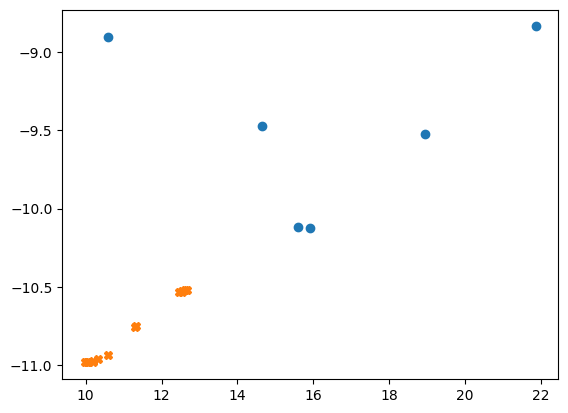

In [7]:
plt.plot(
    ooi_overlapping_bottles.isel(time=2).nitrate,
    -ooi_overlapping_bottles.isel(time=2).temp1,
    "o",
)
plt.plot(
    prof_overlapping_bottles.isel(time=2).nitrate,
    -prof_overlapping_bottles.isel(time=2).temperature,
    "X",
)

In [8]:
# ctd data from NH, nhl_crse_ctd = nh line cruise ctd data
inner_nhl_crse_ctd = xr.open_dataset(
    DATA_DIR / "NHL_Gridded/newport_hydrographic_line_gridded_sections.nc",
)
# fix some xr stuff, assign coords, remove unnecessary dims, etc
inner_nhl_crse_ctd = inner_nhl_crse_ctd.assign_coords(
    date=inner_nhl_crse_ctd["time"].astype("datetime64[D]")
)
inner_nhl_crse_ctd = inner_nhl_crse_ctd.swap_dims({"time": "date"})
inner_nhl_crse_ctd["longitude"] = inner_nhl_crse_ctd["longitude"] - 360
inner_nhl_crse_ctd = inner_nhl_crse_ctd.squeeze()

# nitrate data from NH line cruises, nhl_crse_nit = nh line cruise nitrate data
inner_nhl_crse_nit = pd.read_csv(DATA_DIR / "ship/NH_line_data.csv")

# bin the bottle sample data by date and pressure
nh_pressure_grid = inner_nhl_crse_ctd["pressure"]
nh_time_grid = inner_nhl_crse_ctd["date"]
inner_nhl_crse_nit["Sample Date"] = pd.to_datetime(
    inner_nhl_crse_nit["Sample Date"].values, unit="ns"
)

nitr_tbin, pres_tbin, time_tbin, long_tbin, stat_tbin = [], [], [], [], []
for i, t in enumerate(inner_nhl_crse_ctd["date"].values):
    # find places where nitrate data lines up with ctd data
    # need exact date matches - don't want nearest neighbor for this step
    time_mask = np.where(inner_nhl_crse_nit["Sample Date"] == t)
    for n, d, s, p, lon in zip(
        inner_nhl_crse_nit["NO3 (um)"].values[time_mask],
        inner_nhl_crse_nit["Sample Date"].values[time_mask],
        inner_nhl_crse_nit["Station"].values[time_mask],
        inner_nhl_crse_nit["DepthorPressure (m)"].values[time_mask],
        inner_nhl_crse_nit["Longitude"].values[time_mask],
    ):
        nitr_tbin.append(n)
        pres_tbin.append(p)
        time_tbin.append(d)
        long_tbin.append(lon)
        stat_tbin.append(s)

# make numpy arrays
nitr_tbin, pres_tbin, time_tbin, long_tbin, stat_tbin = (
    np.array(nitr_tbin),
    np.array(pres_tbin),
    np.array(time_tbin),
    np.array(long_tbin),
    np.array(stat_tbin),
)

# make dataarrays for vectorized indexing, doesn't work with np arrays for some reason
pres_targ = xr.DataArray(pres_tbin, dims="date")
time_targ = xr.DataArray(time_tbin, dims="date")
long_targ = xr.DataArray(long_tbin, dims="date")

# bin the ctd data using the arrays from the bottle sample binning, using nearest binning method, e.g., if pressure=0 from bottle, then pressure=1 from ship since this is closest.
inner_nhl_crse = inner_nhl_crse_ctd.sel(
    date=time_targ, pressure=pres_targ, longitude=long_targ, method="nearest"
)

# add nitrate and station
inner_nhl_crse["nitrate"] = (("date"), nitr_tbin)
inner_nhl_crse["station"] = (("date"), stat_tbin)

# view created xarray
inner_nhl_crse = inner_nhl_crse.where(inner_nhl_crse.station == "NH01", drop=True)
inner_nhl_crse = inner_nhl_crse.swap_dims({"date": "time"})

In [9]:
nhl_overlapping_bottles, prof_overlapping_bottles = get_overlapping_bottles(
    profiler=inner_nitrate, ship=inner_nhl_crse
)

36 out of 124 bottle samples overlap with profiler deployments within one day.
88 out of 124 bottle samples do not overlap with profiler deployments within one day.


C:\Users\asche\AppData\Local\Temp\ipykernel_31720\387528787.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


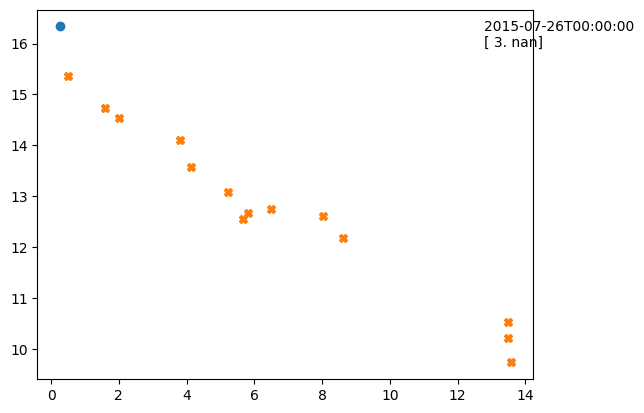

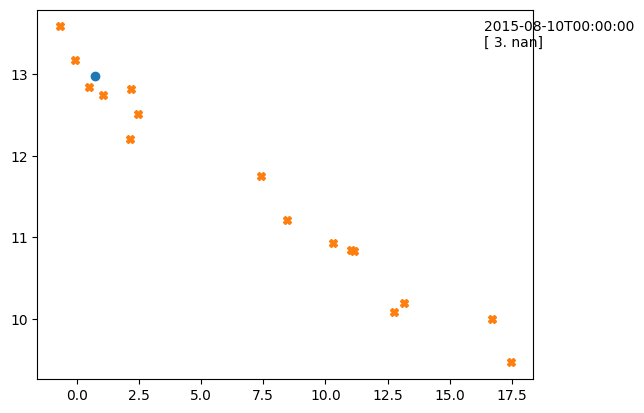

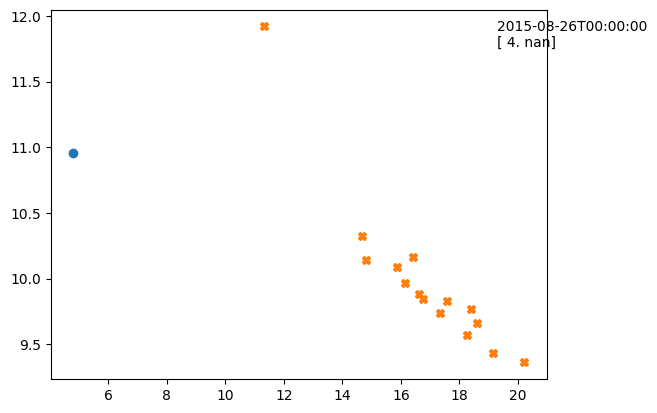

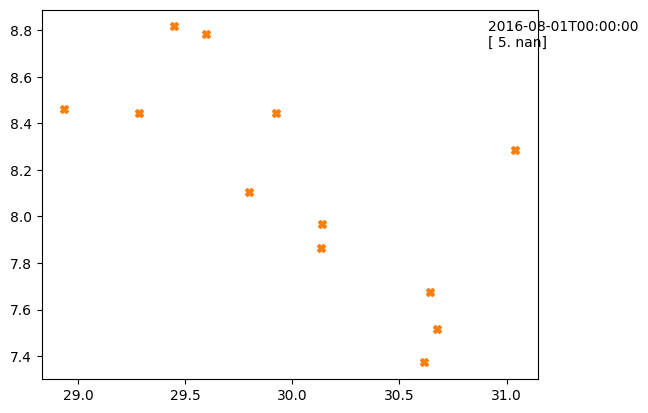

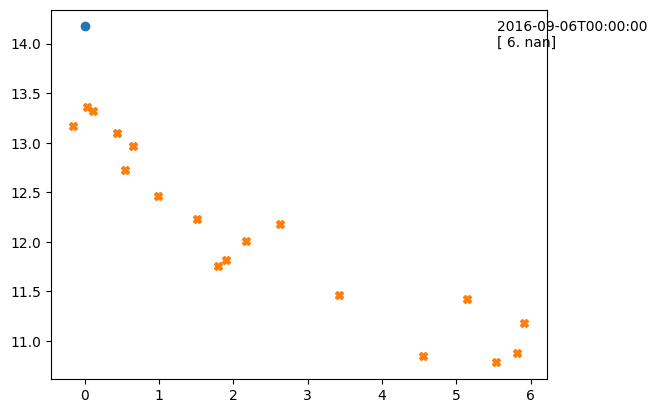

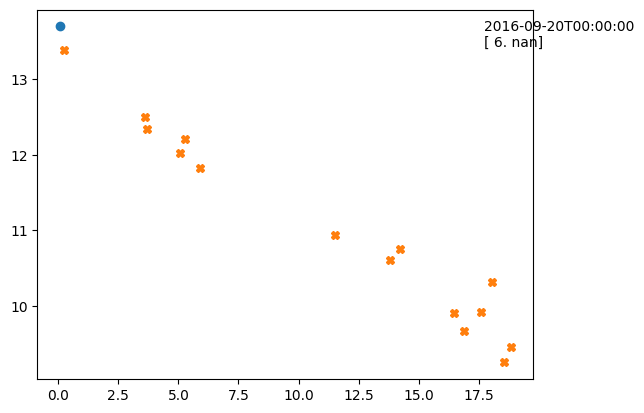

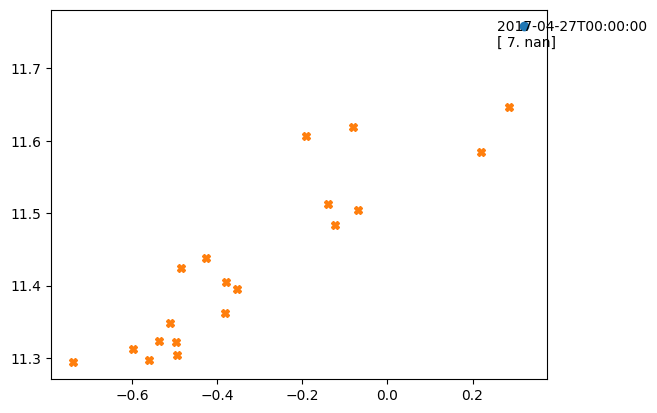

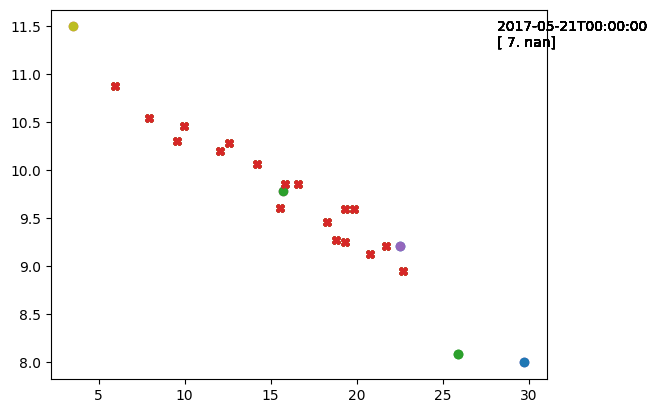

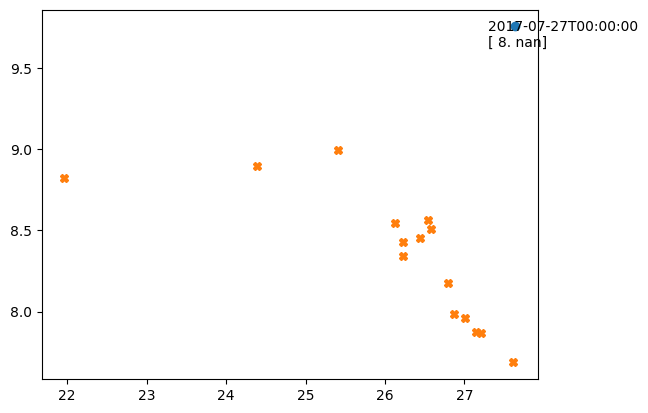

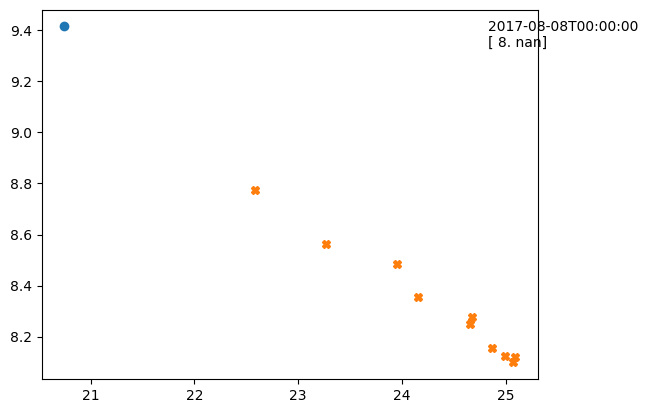

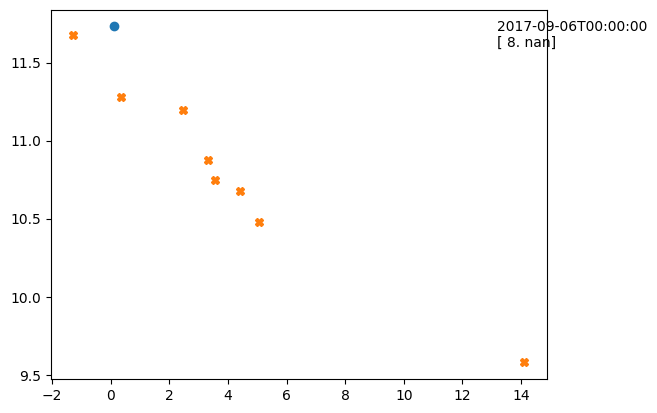

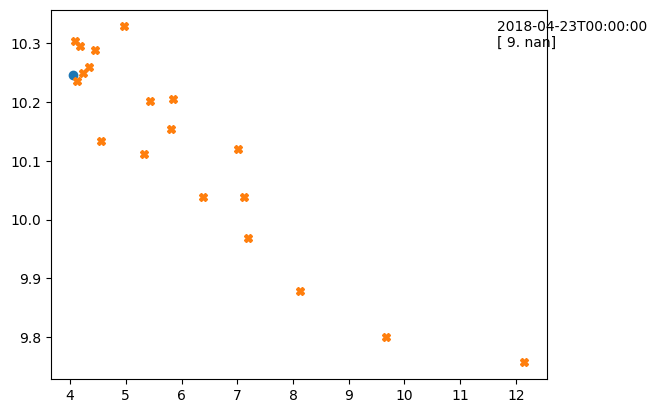

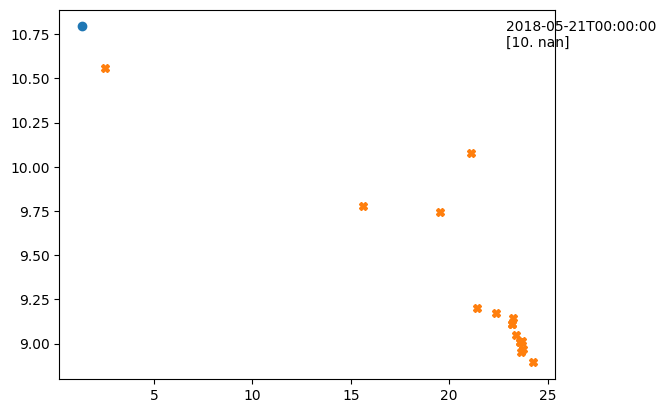

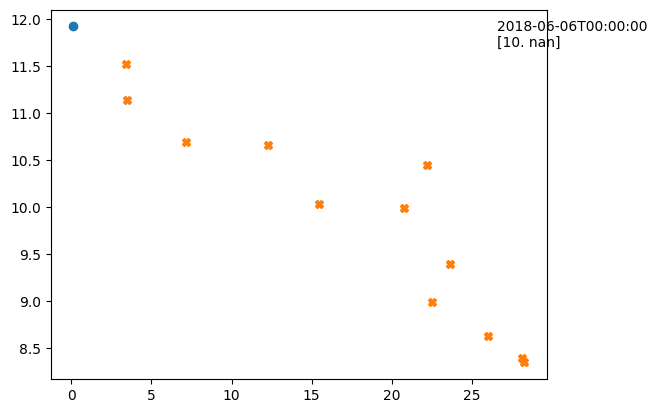

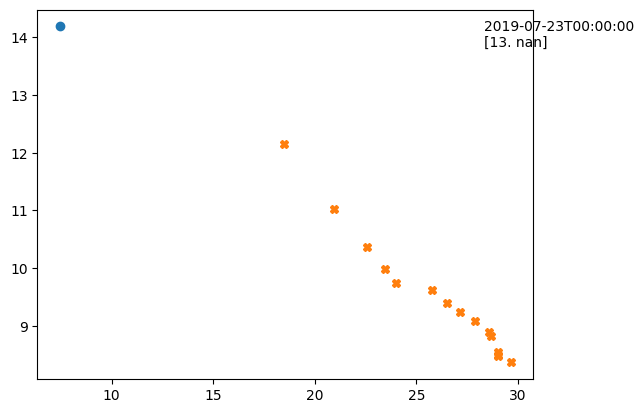

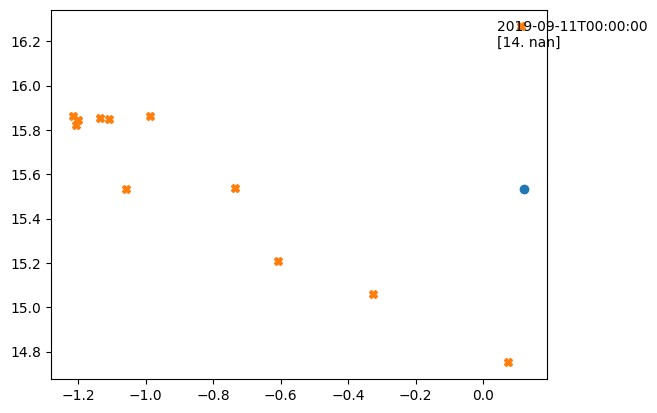

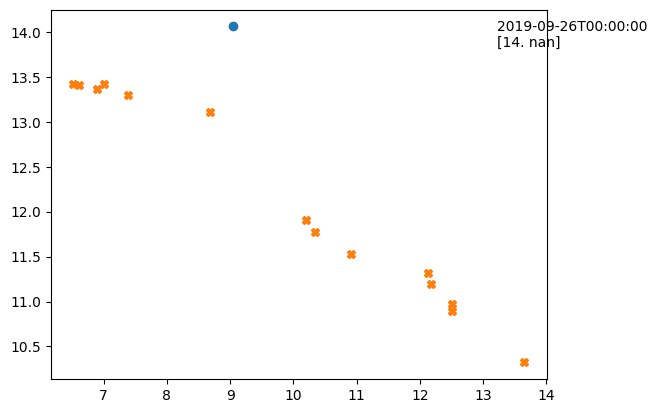

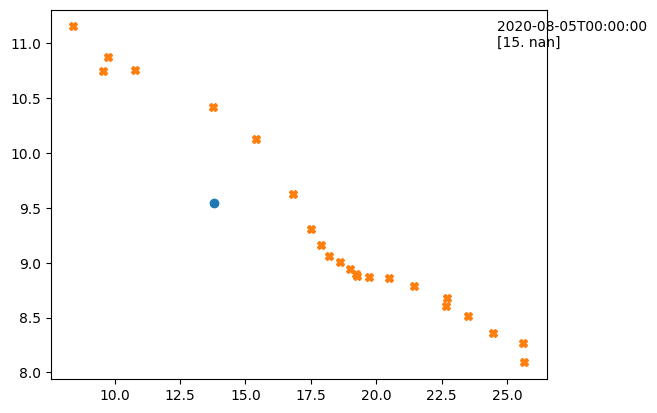

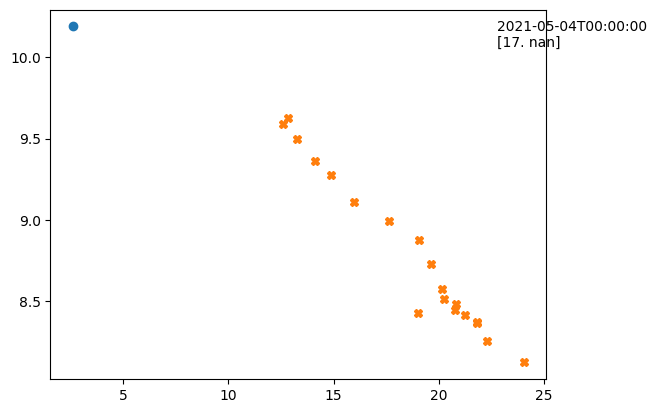

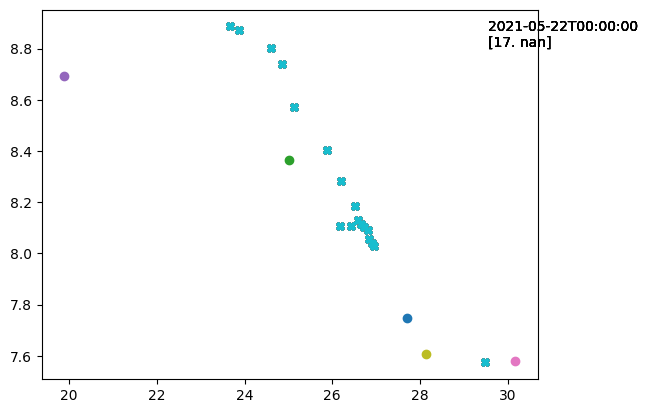

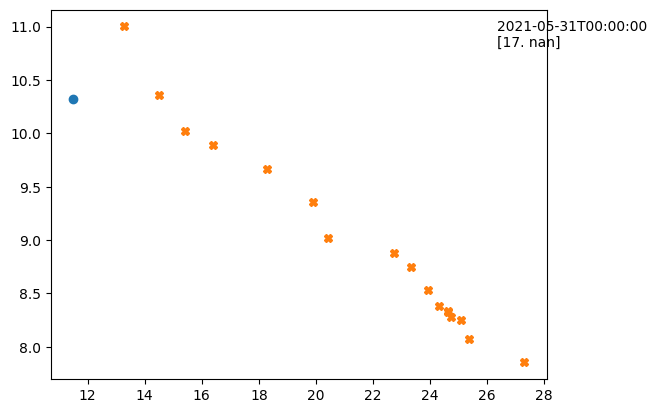

In [10]:
temp = nhl_overlapping_bottles.isel(time=0).date
for i in range(len(nhl_overlapping_bottles.time)):
    if temp != nhl_overlapping_bottles.isel(time=i).date:
        plt.figure()
    plt.plot(
        nhl_overlapping_bottles.isel(time=i).nitrate,
        nhl_overlapping_bottles.isel(time=i).temperature,
        "o",
    )
    plt.plot(
        prof_overlapping_bottles.isel(time=i).nitrate,
        prof_overlapping_bottles.isel(time=i).temperature,
        "X",
    )
    plt.annotate(
        f"{nhl_overlapping_bottles.isel(time=i).date.values}\n{np.unique(prof_overlapping_bottles.isel(time=i).deployment.values)}",
        (0.9, 0.9),
        xycoords="axes fraction",
    )
    temp = nhl_overlapping_bottles.isel(time=i).date

## Mid Shelf Nitrate Bottle Sample Comparison

In [11]:
# loading ooi cruise data df = ooi cruise data
fileList = Path(DATA_DIR / "ship/ea_ship_data/").glob("*.csv")
df_list = []
col_names = [
    "Station",
    "Start Time [UTC]",
    "Start Latitude [degrees]",
    "Start Longitude [degrees]",
    "CTD Pressure [db]",
    "CTD Salinity 1 [psu]",
    "CTD Salinity 2 [psu]",
    "CTD Temperature 1 [deg C]",
    "CTD Temperature 2 [deg C]",
    "Discrete Nitrate [uM]",
]
for f in fileList:
    df_temp = pd.read_csv(DATA_DIR / "ship/ea_ship_data/" / f, usecols=col_names)
    rows = df_temp.loc[df_temp["Station"] == "CE02"]
    df_list.append(rows)

mid_shelf_ooi_crse = pd.concat(df_list)
mid_shelf_ooi_crse = mid_shelf_ooi_crse.rename(
    columns={
        "Start Time [UTC]": "time",
        "Start Latitude [degrees]": "lat",
        "Start Longitude [degrees]": "lon",
        "CTD Pressure [db]": "pressure",
        "CTD Salinity 1 [psu]": "sal1",
        "CTD Salinity 2 [psu]": "sal2",
        "CTD Temperature 1 [deg C]": "temp1",
        "CTD Temperature 2 [deg C]": "temp2",
        "Discrete Nitrate [uM]": "nitrate",
    }
)
mid_shelf_ooi_crse["time"] = pd.to_datetime(mid_shelf_ooi_crse["time"])
# ooi_cruse = mid_shelf_ooi_crse.set_index(["time", "pressure"])
mid_shelf_ooi_crse = mid_shelf_ooi_crse.iloc[
    np.unique(
        mid_shelf_ooi_crse.set_index(["time", "pressure"]).index, return_index=True
    )[1]
]
mid_shelf_ooi_crse = mid_shelf_ooi_crse.set_index(["time", "pressure"])
mid_shelf_ooi_crse = mid_shelf_ooi_crse.to_xarray()
mid_shelf_ooi_crse["time"] = pd.DatetimeIndex(mid_shelf_ooi_crse["time"].values)
mid_shelf_ooi_crse = mid_shelf_ooi_crse.where(
    mid_shelf_ooi_crse.nitrate > -100, drop=True
)
mid_shelf_ooi_crse["pot_density_anom"] = gsw.density.sigma0(
    mid_shelf_ooi_crse["sal1"],
    gsw.conversions.CT_from_t(
        mid_shelf_ooi_crse["sal1"],
        mid_shelf_ooi_crse["temp1"],
        mid_shelf_ooi_crse["pressure"],
    ),
)

In [12]:
ooi_overlapping_bottles, prof_overlapping_bottles = get_overlapping_bottles(
    profiler=midshelf_nitrate, ship=mid_shelf_ooi_crse
)

10 out of 24 bottle samples overlap with profiler deployments within one day.
14 out of 24 bottle samples do not overlap with profiler deployments within one day.


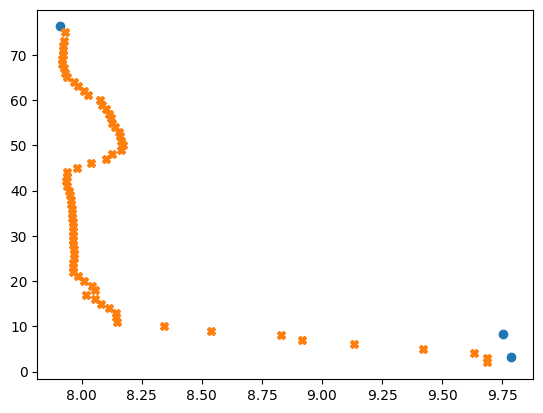

In [13]:
plt.plot(
    ooi_overlapping_bottles.isel(time=-1).temp1,
    ooi_overlapping_bottles.isel(time=-1).pressure,
    "o",
)
plt.plot(
    prof_overlapping_bottles.isel(time=-1).temperature,
    prof_overlapping_bottles.isel(time=-1).depth,
    "X",
)

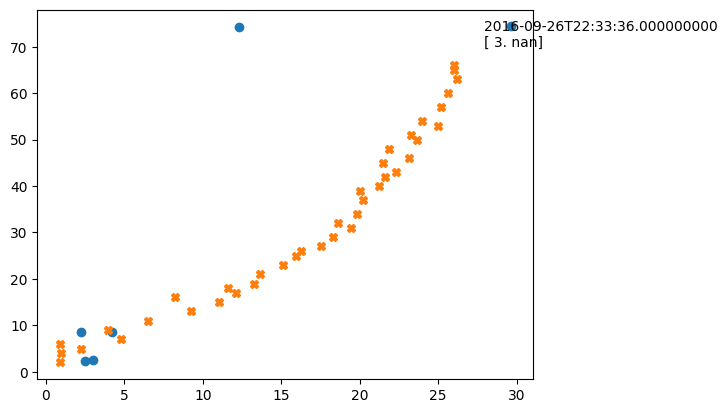

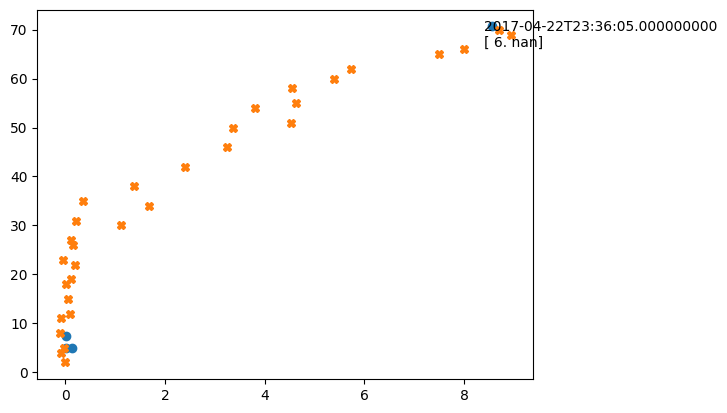

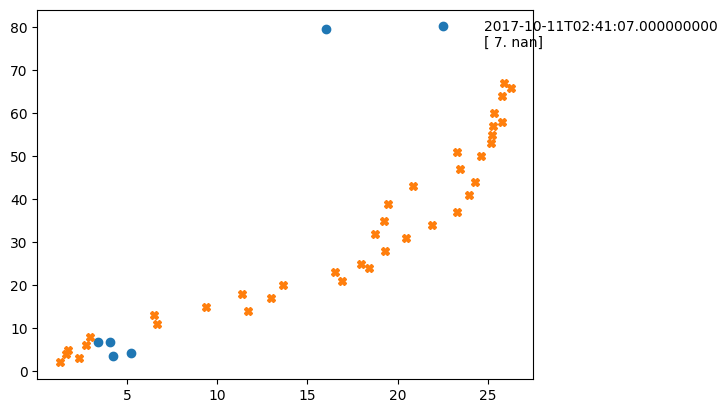

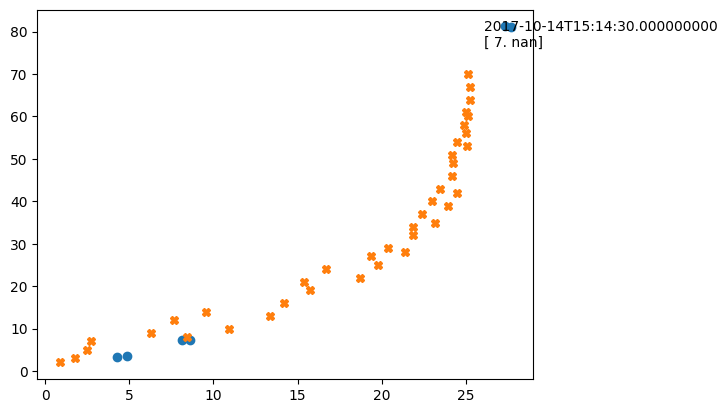

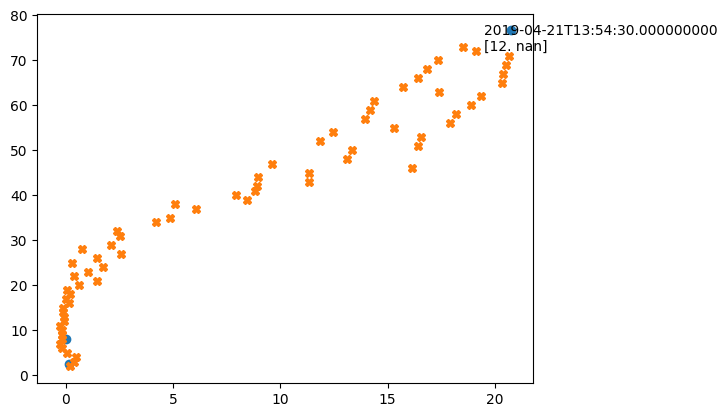

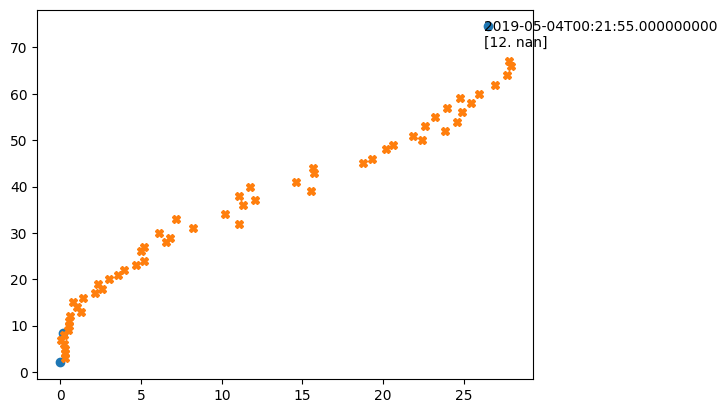

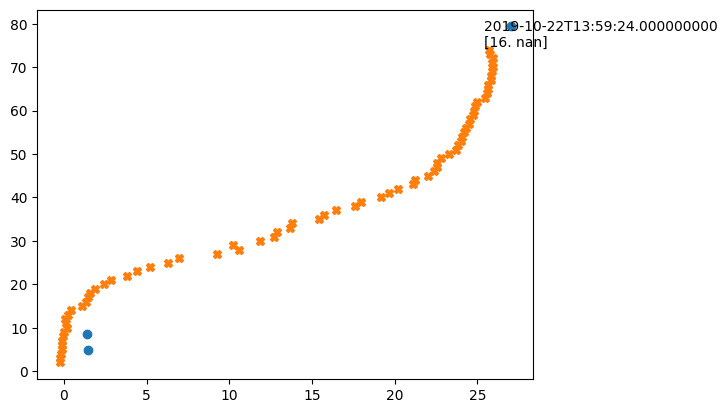

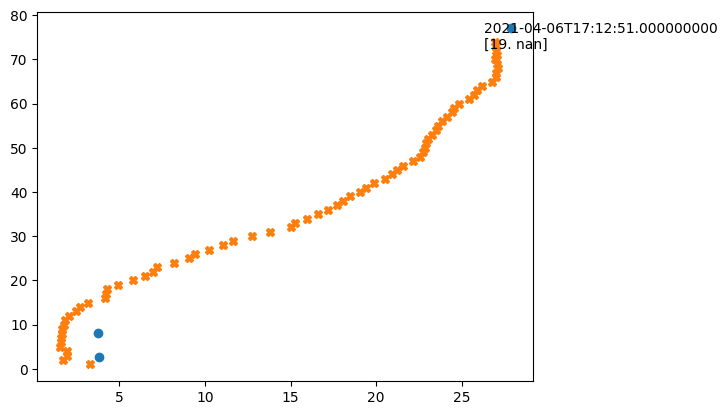

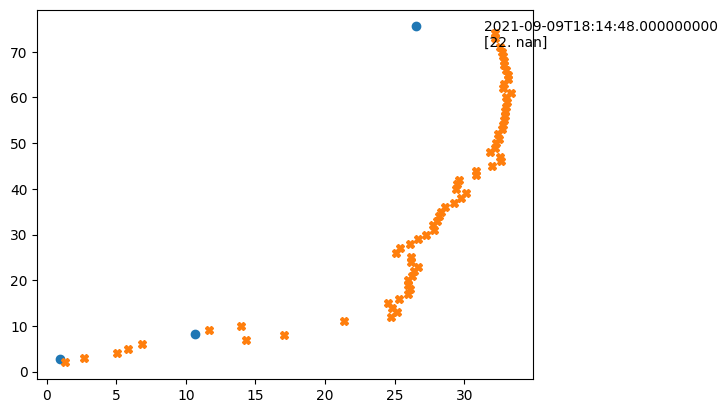

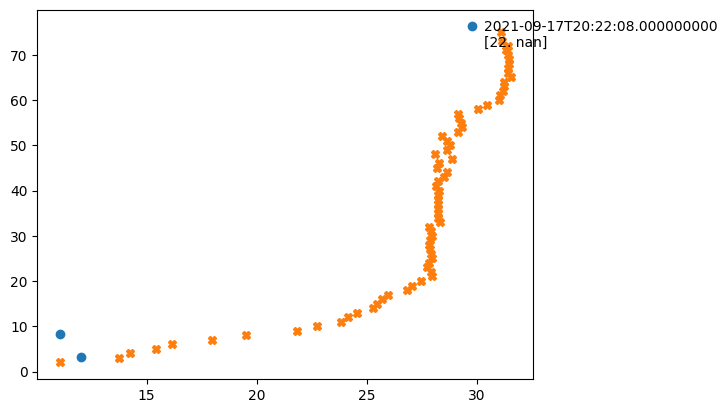

In [14]:
temp = ooi_overlapping_bottles.isel(time=0).time
for i in range(len(ooi_overlapping_bottles.time)):
    plt.figure()
    plt.plot(
        ooi_overlapping_bottles.isel(time=i).nitrate,
        ooi_overlapping_bottles.isel(time=i).pressure,
        "o",
    )
    plt.plot(
        prof_overlapping_bottles.isel(time=i).nitrate,
        prof_overlapping_bottles.isel(time=i).depth,
        "X",
    )
    plt.annotate(
        f"{ooi_overlapping_bottles.isel(time=i).time.values}\n{np.unique(prof_overlapping_bottles.isel(time=i).deployment.values)}",
        (0.9, 0.9),
        xycoords="axes fraction",
    )
    temp = ooi_overlapping_bottles.isel(time=i).time

## Nitrate Density Relationship and Comparison with Bottle Samples

Mean N below 25.8 sigma: 6.552617833228939
Mean N above 25.8 sigma: 25.843337232353228
Mean N below 25.8 sigma: 9.266042720262504
Mean N above 25.8 sigma: 27.34084088292088


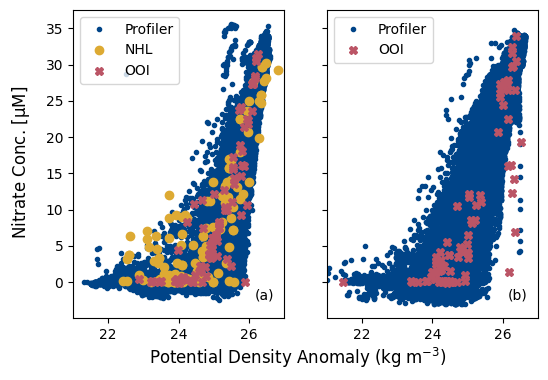

In [15]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(6, 4), sharey=True)
# ax0.plot(midshelf_nitrate.density, midshelf_nitrate.nitrate ,'.', color='#004488', label='Profiler', rasterized=True)
# ax0.plot(nhl_crse.potential_density, nhl_crse.nitrate, 'o', color='#DDAA33', label='NHL')
ax0.plot(
    inner_nitrate["density"],
    inner_nitrate["nitrate"],
    ".",
    color="#004488",
    label="Profiler",
)
ax0.plot(
    inner_nhl_crse["potential_density"],
    inner_nhl_crse["nitrate"],
    "o",
    color="#DDAA33",
    label="NHL",
)
ax0.plot(
    inner_ooi_crse["pot_density_anom"],
    inner_ooi_crse["nitrate"],
    "X",
    color="#BB5566",
    label="OOI",
)
ax0.set_xlim(21, 27)

handles, labels = ax0.get_legend_handles_labels()
by_label = dict(
    zip(labels, handles)
)  # dicts can't have duplicate keys, avoids duplicate legend entries
ax0.legend(by_label.values(), by_label.keys())
print(
    f"Mean N below 25.8 sigma: {np.nanmean(inner_nitrate.where(inner_nitrate['density'] < 25.8)['nitrate'])}"
)
print(
    f"Mean N above 25.8 sigma: {np.nanmean(inner_nitrate.where(inner_nitrate['density'] > 25.8)['nitrate'])}"
)

ax1.plot(
    midshelf_nitrate["density"],
    midshelf_nitrate["nitrate"],
    ".",
    color="#004488",
    label="Profiler",
    rasterized=True,
)
ax1.plot(
    mid_shelf_ooi_crse["pot_density_anom"],
    mid_shelf_ooi_crse["nitrate"],
    "X",
    color="#BB5566",
    label="OOI",
)
ax1.set_xlim(21, 27)
# ax1.set_xlabel('Density Anomaly ($\mathsf{kg \; m^{-3}}$)')
# ax1.set_ylabel('Nitrate Conc. [$\mathsf{\mu M}$]')
handles, labels = ax1.get_legend_handles_labels()
by_label = dict(
    zip(labels, handles)
)  # dicts can't have duplicate keys, avoids duplicate legend entries
ax1.legend(by_label.values(), by_label.keys())
fig.supxlabel("Potential Density Anomaly ($\\mathsf{kg \\; m^{-3}}$)", y=-0.02)
fig.supylabel("Nitrate Conc. [$\\mathsf{\\mu M}$]", x=0.02)

ax0.text(
    0.95, 0.05, "(a)", transform=ax0.transAxes, fontsize=10, ha="right", va="bottom"
)
ax1.text(
    0.95, 0.05, "(b)", transform=ax1.transAxes, fontsize=10, ha="right", va="bottom"
)

print(
    f"Mean N below 25.8 sigma: {np.nanmean(midshelf_nitrate.where(midshelf_nitrate['density'] < 25.8)['nitrate'])}"
)
print(
    f"Mean N above 25.8 sigma: {np.nanmean(midshelf_nitrate.where(midshelf_nitrate['density'] > 25.8)['nitrate'])}"
)

plt.savefig(
    FIGURES_DIR / "nitrate-density.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=1200,
)